# CSC8645 — Advanced AI
# Assignment: Task 2 — Multimodal Idiomaticity Representation

## Student Name   : Krishnanand Sagar
## Student Number : 250569452

## Task Overview:
This notebook implements a multimodal idiomaticity prediction system.
Given a nominal compound (e.g. "bad apple"), a context sentence, and three candidate images, the model predicts which image best represents the sense (idiomatic or literal) in which the compound is used. The pipeline progresses from text-only baselines to a fine-tuned DeBERTa-v3 cross-encoder with LLM augmentation and meta-learner stacking.

## Pipeline Summary:
### Baseline 1 — Caption Similarity (all-mpnet-base-v2)
### Baseline 2 — CLIP-Large Zero-Shot (ViT-L/14)
### Final 1    — DeBERTa-v3 Fine-Tuned Cross-Encoder
### Final 2    — LLM-Augmented Ensemble (CLIP + Caption + DeBERTa)
### Final 3    — Meta-Learner Stacking (Logistic Regression)

## Reference:
Tayyar Madabushi et al., "SemEval-2022 Task 2:
Multilingual Idiomaticity Detection", SemEval 2022.

## Block 1 - Environment Setup

Installs and upgrades all required libraries to versions compatible with Python 3.12 on Colab Pro+

In [1]:
import subprocess, sys

packages = [
    "torchmetrics",
    "scikit-image",
    "accelerate",
    "sentence-transformers"
]

for pkg in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        check=True
    )

print("All packages ready ✓")
print("Continue directly to Block 2.")

All packages ready ✓
Continue directly to Block 2.


## Block 2 - Library Imports and Device Configuration

Imports all required libraries and sets the computation device(CUDA GPU).
Random seeds are fixed at 42 across Python, NumPy and PyTorch to ensure reproducibitly.

In [2]:
from packaging import version
import transformers
print(f"Transformers: {transformers.__version__}")
assert version.parse(transformers.__version__) >= version.parse("4.46.0"), \
    "Too old — re-run Block 1"

import os, zipfile, warnings, random, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    CLIPModel, CLIPProcessor,
    AutoTokenizer, AutoModel,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup
)
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

use_amp = torch.cuda.is_available()
print("\nAll imports successful ✓")

Transformers: 5.0.0

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB

All imports successful ✓


## Block 2B - Pipeline Flowchart
Generates a visual flowchart of the complete Task2 methodology pipeline - from raw input through preprocessing, baseline methods, LLM augmentation, fine-tuning, ensemble fusion, and evaluation.

Mounted at /content/drive


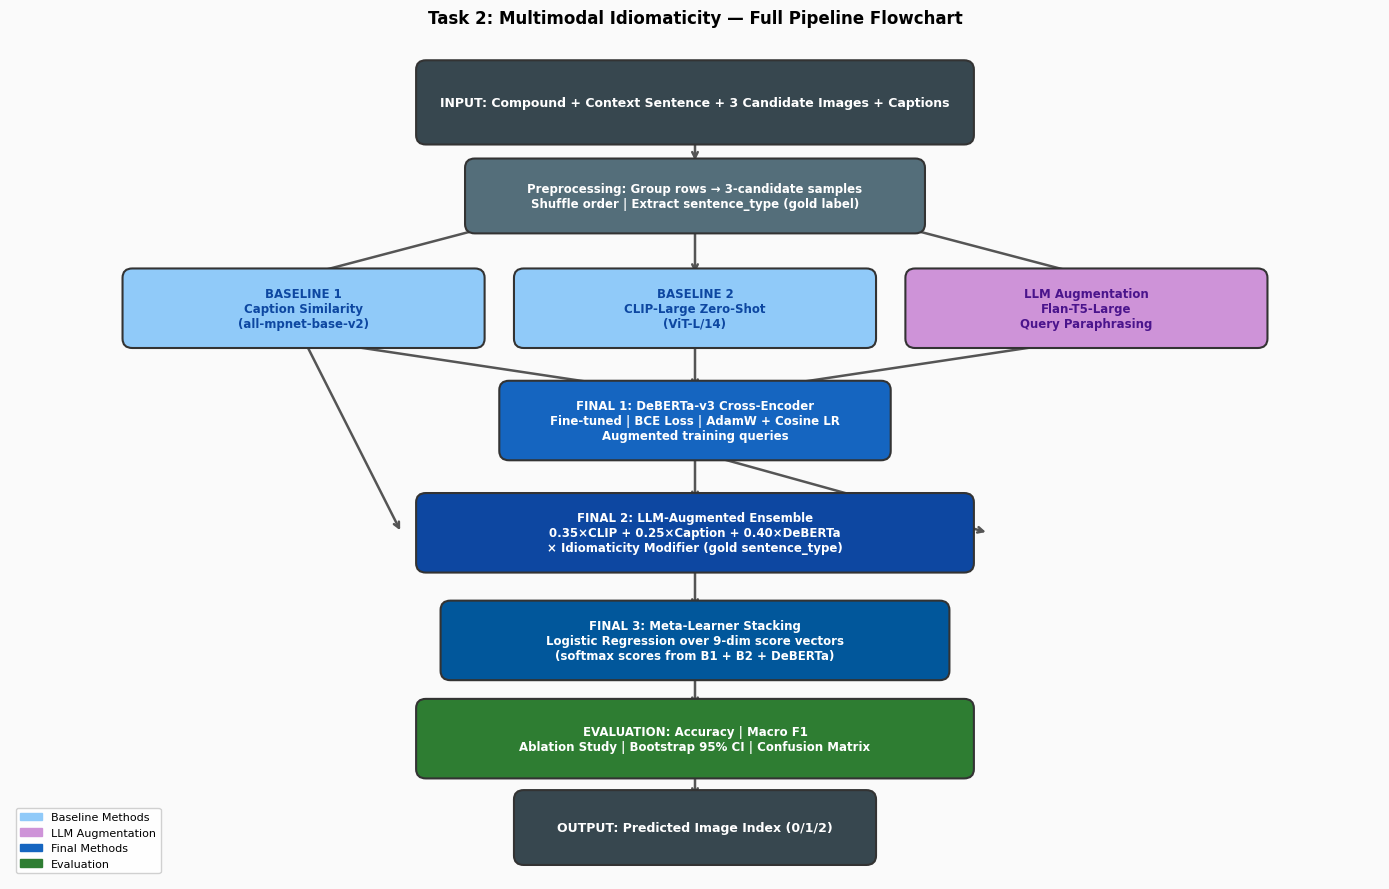

Flowchart saved ✓


In [10]:
# Pipeline flowchart — saved as PNG for report
import matplotlib.patches as mpatches
import os

# Define OUT_DIR here in case Block 3 hasn't run yet
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
OUT_DIR = '/content/drive/MyDrive/Advanced AI/task2_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14); ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

def box(ax, x, y, w, h, label, color='#1565C0', fontsize=9,
        textcolor='white', style='round,pad=0.1'):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-w/2, y-h/2), w, h,
        boxstyle=style, linewidth=1.5,
        edgecolor='#333333', facecolor=color, zorder=3
    ))
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, color=textcolor,
            fontweight='bold', zorder=4,
            wrap=True, multialignment='center')

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#555555',
                                lw=1.8), zorder=2)

# Input
box(ax, 7, 8.3, 5.5, 0.7,
    'INPUT: Compound + Context Sentence + 3 Candidate Images + Captions',
    color='#37474F', fontsize=9)

# Preprocessing
box(ax, 7, 7.3, 4.5, 0.6,
    'Preprocessing: Group rows → 3-candidate samples\n'
    'Shuffle order | Extract sentence_type (gold label)',
    color='#546E7A', fontsize=8.5)
arrow(ax, 7, 7.95, 7, 7.65)

# Baselines
box(ax, 3, 6.1, 3.5, 0.65,
    'BASELINE 1\nCaption Similarity\n(all-mpnet-base-v2)',
    color='#90CAF9', textcolor='#0D47A1', fontsize=8.5)
box(ax, 7, 6.1, 3.5, 0.65,
    'BASELINE 2\nCLIP-Large Zero-Shot\n(ViT-L/14)',
    color='#90CAF9', textcolor='#0D47A1', fontsize=8.5)
arrow(ax, 5, 7.0, 3, 6.45)
arrow(ax, 7, 7.0, 7, 6.45)

# LLM Augmentation
box(ax, 11, 6.1, 3.5, 0.65,
    'LLM Augmentation\nFlan-T5-Large\nQuery Paraphrasing',
    color='#CE93D8', textcolor='#4A148C', fontsize=8.5)
arrow(ax, 9, 7.0, 11, 6.45)

# Fine-tuning
box(ax, 7, 4.9, 3.8, 0.65,
    'FINAL 1: DeBERTa-v3 Cross-Encoder\n'
    'Fine-tuned | BCE Loss | AdamW + Cosine LR\n'
    'Augmented training queries',
    color='#1565C0', fontsize=8.5)
arrow(ax, 3,  5.77, 6.5, 5.22)
arrow(ax, 7,  5.77, 7,   5.22)
arrow(ax, 11, 5.77, 7.5, 5.22)

# Ensemble
box(ax, 7, 3.7, 5.5, 0.65,
    'FINAL 2: LLM-Augmented Ensemble\n'
    '0.35×CLIP + 0.25×Caption + 0.40×DeBERTa\n'
    '× Idiomaticity Modifier (gold sentence_type)',
    color='#0D47A1', fontsize=8.5)
arrow(ax, 3,  5.77, 4,   3.7)
arrow(ax, 7,  4.57, 7,   4.02)
arrow(ax, 7,  4.57, 10,  3.7)

# Meta-learner
box(ax, 7, 2.55, 5.0, 0.65,
    'FINAL 3: Meta-Learner Stacking\n'
    'Logistic Regression over 9-dim score vectors\n'
    '(softmax scores from B1 + B2 + DeBERTa)',
    color='#01579B', fontsize=8.5)
arrow(ax, 7, 3.37, 7, 2.87)

# Evaluation
box(ax, 7, 1.5, 5.5, 0.65,
    'EVALUATION: Accuracy | Macro F1\n'
    'Ablation Study | Bootstrap 95% CI | Confusion Matrix',
    color='#2E7D32', fontsize=8.5)
arrow(ax, 7, 2.22, 7, 1.82)

# Output
box(ax, 7, 0.55, 3.5, 0.6,
    'OUTPUT: Predicted Image Index (0/1/2)',
    color='#37474F', fontsize=9)
arrow(ax, 7, 1.17, 7, 0.85)

# Legend
legend_items = [
    mpatches.Patch(color='#90CAF9', label='Baseline Methods'),
    mpatches.Patch(color='#CE93D8', label='LLM Augmentation'),
    mpatches.Patch(color='#1565C0', label='Final Methods'),
    mpatches.Patch(color='#2E7D32', label='Evaluation')
]
ax.legend(handles=legend_items, loc='lower left',
          fontsize=8, framealpha=0.9)
ax.set_title('Task 2: Multimodal Idiomaticity — Full Pipeline Flowchart',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pipeline_flowchart.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print("Flowchart saved ✓")

## Block 3 - Drive Mount and Data Extraction

Mounts Google Drive and extracts the Task2 NLP dataset zip file.
Prints the complete folder tree to confirm structure before laoding any data.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH   = '/content/drive/MyDrive/Advanced AI/Task+2+NLP+Dataset.zip'
EXTRACT_TO = '/content/task2_data'
OUT_DIR    = '/content/drive/MyDrive/Advanced AI/task2_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(EXTRACT_TO):
    print("Extracting ZIP...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print("Done.")
else:
    print("Already extracted.")

print("\n=== Folder structure ===")
for root, dirs, files in os.walk(EXTRACT_TO):
    depth  = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth <= 3:
        for f in files[:6]:
            print(f"{indent}  {f}")
        if len(files) > 6:
            print(f"{indent}  ... ({len(files)} total)")

Mounted at /content/drive
Extracting ZIP...
Done.

=== Folder structure ===
task2_data/
  val/
    val.csv
    images/
      90925081313.png
      12066404241.png
      92619052441.png
      66880647761.png
      49177713448.png
      87303309822.png
      ... (27 total)
  test/
    test.csv
    images/
      12319434549.png
      03293059977.png
      45153820818.png
      58491774071.png
      59839303756.png
      58529637108.png
      ... (27 total)
  train/
    train.csv
    images/
      21275236775.png
      94649072829.png
      04129294826.png
      47140387353.png
      32437056738.png
      89307973022.png
      ... (231 total)


## Block 4 - Auto-Discover Dataset Files

Automatically scans the extracted dataset folder to locate all CSV files and image directions.


In [4]:
csv_files = {}
for root, dirs, files in os.walk(EXTRACT_TO):
    for f in files:
        if f.endswith('.csv'):
            key = f.replace('.csv','').lower().strip()
            csv_files[key] = os.path.join(root, f)
            print(f"CSV  : '{key}'  →  {os.path.join(root, f)}")

img_dirs = {}
for root, dirs, files in os.walk(EXTRACT_TO):
    imgs = [f for f in files
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    if len(imgs) > 5:
        parent = os.path.basename(os.path.dirname(root))
        img_dirs[parent] = root
        print(f"Imgs : '{parent}'  →  {root}  ({len(imgs)} files)")

print(f"\nCSV keys   : {list(csv_files.keys())}")
print(f"Image keys : {list(img_dirs.keys())}")

CSV  : 'val'  →  /content/task2_data/val/val.csv
CSV  : 'test'  →  /content/task2_data/test/test.csv
CSV  : 'train'  →  /content/task2_data/train/train.csv
Imgs : 'val'  →  /content/task2_data/val/images  (27 files)
Imgs : 'test'  →  /content/task2_data/test/images  (27 files)
Imgs : 'train'  →  /content/task2_data/train/images  (231 files)

CSV keys   : ['val', 'test', 'train']
Image keys : ['val', 'test', 'train']


## Block 5 - Load DataFrames and Inspect Structure

Loads training, validation, and test CSVs into pandas DataFrames.


In [5]:
# Update keys to match what Block 4 printed
TRAIN_KEY = 'train'
DEV_KEY   = 'val'
TEST_KEY  = 'test'

train_df = pd.read_csv(csv_files[TRAIN_KEY])
dev_df   = pd.read_csv(csv_files[DEV_KEY])
test_df  = pd.read_csv(csv_files[TEST_KEY])

print(f"Train : {train_df.shape}")
print(f"Dev   : {dev_df.shape}")
print(f"Test  : {test_df.shape}")
print(f"\nColumns:\n{train_df.columns.tolist()}")
print(f"\nFirst 2 rows:")
display(train_df.head(2))

Train : (231, 6)
Dev   : (27, 6)
Test  : (27, 6)

Columns:
['compound', 'sentence_type', 'sentence', 'image_name', 'image_caption', 'label']

First 2 rows:


,compound,sentence_type,sentence,image_name,image_caption,label
0,hot potato,idiomatic,The pipeline is set to create a human rights d...,46916305307.png,The image depicts two cartoon-style characters...,1
1,hot potato,idiomatic,The pipeline is set to create a human rights d...,00316911039.png,The image depicts an oven with a large potato ...,0


## Block 6 - Column Mapping, Sample Construction and Validation

Maps dataset column names to code constants. Group the flat CSVs structure into 3-candidate sample dictionaries with deterministically shuffled candidate order to prevent positional bias.

In [6]:
COL_COMPOUND = 'compound'
COL_CONTEXT  = 'sentence'
COL_SENT_TYPE = 'sentence_type'
COL_IMG      = 'image_name'
COL_CAP      = 'image_caption'
COL_LABEL    = 'label'

TRAIN_IMG = img_dirs.get('train', list(img_dirs.values())[0] if img_dirs else '')
DEV_IMG   = img_dirs.get('val',   list(img_dirs.values())[0] if img_dirs else '')
TEST_IMG  = img_dirs.get('test',  list(img_dirs.values())[0] if img_dirs else '')

def load_img(path):
    try:
        return Image.open(path).convert('RGB')
    except Exception:
        return Image.new('RGB', (224, 224), color=(180, 180, 180))

def softmax_norm(scores):
    s = np.array(scores, dtype=np.float64)
    e = np.exp(s - s.max())
    return (e / e.sum()).astype(np.float32)

def build_samples(df, img_dir, seed=42):
    """
    Groups flat df into 3-candidate samples.
    Shuffles candidate order within each sample so true_label
    is not always 0 (fixes meta-learner single-class error).
    seed=42 gives reproducible shuffling.
    """
    samples = []
    rng     = random.Random(seed)
    grouped = df.groupby([COL_COMPOUND, COL_CONTEXT], sort=False)

    for (compound, sentence), grp in grouped:
        grp = grp.reset_index(drop=True)
        if len(grp) != 3:
            continue

        # Find which position (0/1/2) is correct before shuffle
        correct_positions = grp.index[grp[COL_LABEL] == 1].tolist()
        if not correct_positions:
            continue
        correct_orig = correct_positions[0]   # 0, 1, or 2

        # Shuffle candidate order
        indices = [0, 1, 2]
        rng.shuffle(indices)

        # Find where the correct candidate landed after shuffle
        true_idx = indices.index(correct_orig)

        samples.append({
            'compound'  : compound,
            'sentence'  : sentence,
            'sent_type' : grp[COL_SENT_TYPE].iloc[0],
            'images'    : [os.path.join(img_dir,
                           str(grp[COL_IMG].iloc[i])) for i in indices],
            'captions'  : [str(grp[COL_CAP].iloc[i]) for i in indices],
            'true_label': true_idx
        })
    return samples

# Different seeds so train/dev/test have different shuffles
# but are all reproducible
print("Building sample groups...")
train_samples = build_samples(train_df, TRAIN_IMG, seed=42)
dev_samples   = build_samples(dev_df,   DEV_IMG,   seed=99)
test_samples  = build_samples(test_df,  TEST_IMG,  seed=7)

print(f"Train samples : {len(train_samples)}")
print(f"Dev samples   : {len(dev_samples)}")
print(f"Test samples  : {len(test_samples)}")

# Verify true_label distribution — must NOT be all 0
from collections import Counter
train_label_dist = Counter(s['true_label'] for s in train_samples)
dev_label_dist   = Counter(s['true_label'] for s in dev_samples)
print(f"\nTrain true_label distribution : {dict(sorted(train_label_dist.items()))}")
print(f"Dev   true_label distribution : {dict(sorted(dev_label_dist.items()))}")
# If still all 0 here — paste output and I'll investigate the CSV structure

# Sentence type distribution
type_counts = train_df.drop_duplicates(
    subset=[COL_COMPOUND, COL_CONTEXT])[COL_SENT_TYPE].value_counts()
print(f"\nSentence types:\n{type_counts}")

# Sanity check image loading
img = load_img(train_samples[0]['images'][0])
is_grey = (img.size==(224,224) and img.getpixel((0,0))==(180,180,180))
print(f"\nImage load: {'⚠️ GREY — fix path' if is_grey else str(img.size)+' ✓'}")

# Set true_labs for dev (used throughout)
true_labs = [s['true_label'] for s in dev_samples]
print(f"\ntrue_labs sample: {true_labs[:9]}")

Building sample groups...
Train samples : 77
Dev samples   : 9
Test samples  : 9

Train true_label distribution : {0: 27, 1: 24, 2: 26}
Dev   true_label distribution : {0: 3, 1: 2, 2: 4}

Sentence types:
sentence_type
idiomatic    77
Name: count, dtype: int64

Image load: (1024, 1024) ✓

true_labs sample: [0, 2, 2, 2, 0, 1, 0, 2, 1]


## Block 7 - EDA: Distributions

Visualises the dataset structure thorugh 4 plots. These observations inform model design choices

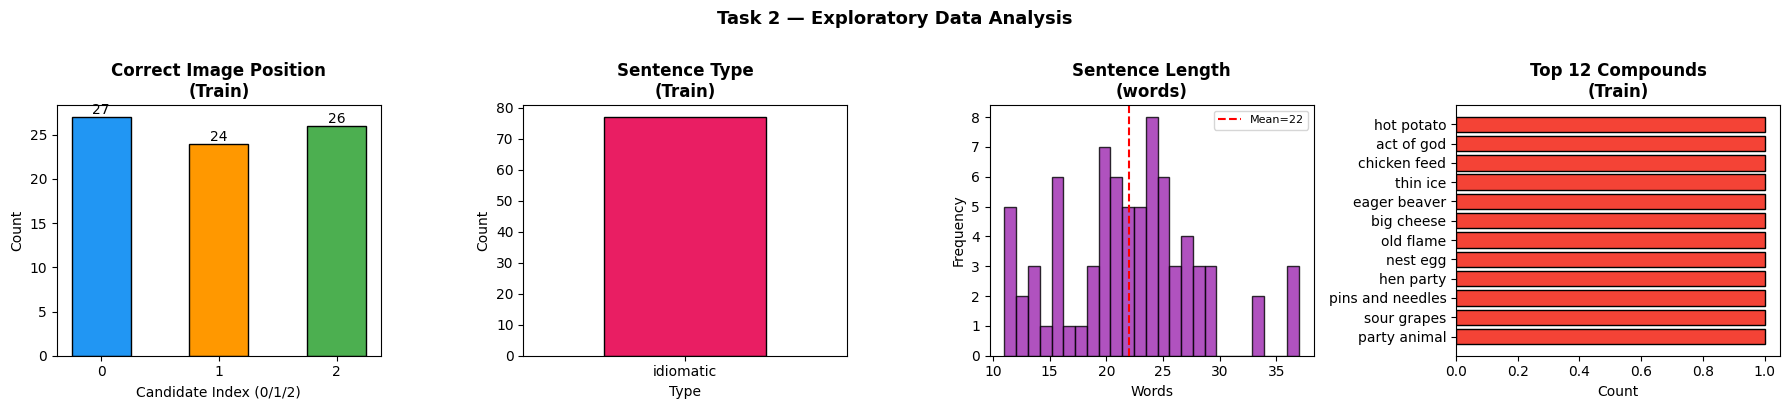

Unique compounds (train)  : 77
Unique compounds (dev)    : 9
Total samples (train)     : 77
Idiomatic samples (train) : 77
Literal samples (train)   : 0


In [15]:
# Use deduplicated df for sentence-level stats
train_meta = train_df.drop_duplicates(
    subset=[COL_COMPOUND, COL_CONTEXT]).copy()
train_meta['ctx_len'] = train_meta[COL_CONTEXT].apply(
    lambda x: len(str(x).split()))

fig = plt.figure(figsize=(18, 4))
gs  = gridspec.GridSpec(1, 4, figure=fig)

# Label balance — how often is each position (0/1/2) correct
ax1 = fig.add_subplot(gs[0])
pos_counts = []
for s in train_samples:
    pos_counts.append(s['true_label'])
pos_series = pd.Series(pos_counts).value_counts().sort_index()
ax1.bar(pos_series.index, pos_series.values,
        color=['#2196F3','#FF9800','#4CAF50'],
        edgecolor='black', width=0.5)
ax1.set_title('Correct Image Position\n(Train)', fontweight='bold')
ax1.set_xlabel('Candidate Index (0/1/2)'); ax1.set_ylabel('Count')
ax1.set_xticks([0,1,2])
for i, v in zip(pos_series.index, pos_series.values):
    ax1.text(i, v+0.3, str(v), ha='center', fontsize=10)

# Sentence type (idiomatic vs literal)
ax2 = fig.add_subplot(gs[1])
type_counts.plot(kind='bar', ax=ax2,
                 color=['#E91E63','#00BCD4'],
                 edgecolor='black', width=0.5)
ax2.set_title('Sentence Type\n(Train)', fontweight='bold')
ax2.set_xlabel('Type'); ax2.set_ylabel('Count')
ax2.set_xticklabels(type_counts.index, rotation=0)

# Sentence length
ax3 = fig.add_subplot(gs[2])
ax3.hist(train_meta['ctx_len'], bins=25, color='#9C27B0',
         edgecolor='black', alpha=0.8)
ax3.axvline(train_meta['ctx_len'].mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f"Mean={train_meta['ctx_len'].mean():.0f}")
ax3.set_title('Sentence Length\n(words)', fontweight='bold')
ax3.set_xlabel('Words'); ax3.set_ylabel('Frequency')
ax3.legend(fontsize=8)

# Top compounds
ax4 = fig.add_subplot(gs[3])
top = train_df[COL_COMPOUND].value_counts().head(12) // 3  # divide by 3 (rows per sample)
ax4.barh(top.index, top.values, color='#F44336', edgecolor='black')
ax4.set_title('Top 12 Compounds\n(Train)', fontweight='bold')
ax4.set_xlabel('Count'); ax4.invert_yaxis()

plt.suptitle('Task 2 — Exploratory Data Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'eda_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Unique compounds (train)  : {train_df[COL_COMPOUND].nunique()}")
print(f"Unique compounds (dev)    : {dev_df[COL_COMPOUND].nunique()}")
print(f"Total samples (train)     : {len(train_samples)}")
print(f"Idiomatic samples (train) : {sum(1 for s in train_samples if s['sent_type']=='idiomatic')}")
print(f"Literal samples (train)   : {sum(1 for s in train_samples if s['sent_type']=='literal')}")

## Block 8 - EDA: Sample Visualisation

Displays represntative training examples showing the compound, context sentence, all three candidate images with captions and correct answer.

Compound      : hot potato
Sentence type : idiomatic
Context       : The pipeline is set to create a human rights disaster in the region, and has become such a hot potato that the Bank has postponed the decision.
True label    : 1


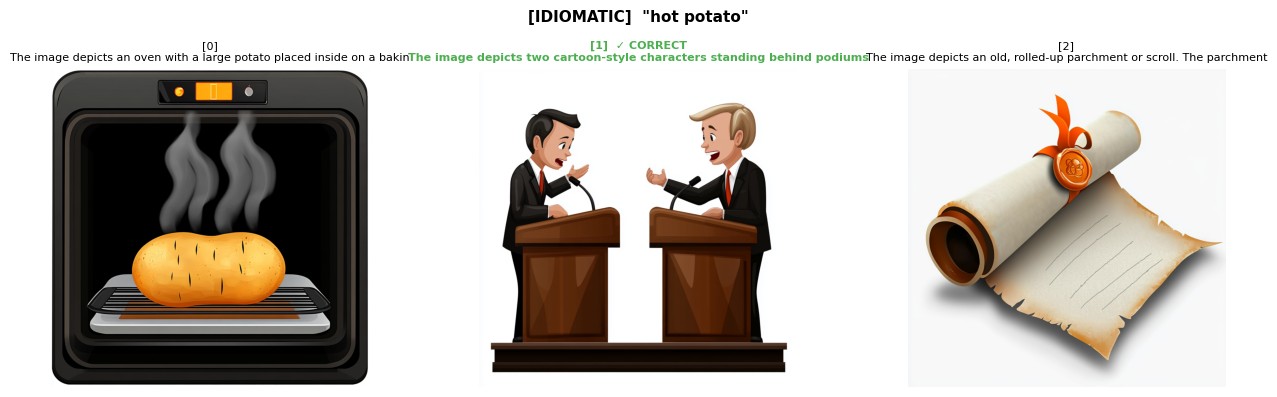

Compound      : thin ice
Sentence type : idiomatic
Context       : Investors in both instances were already tiptoeing on thin ice, knowing that the longest US stock market bull run in history was showing signs of overheating.
True label    : 2


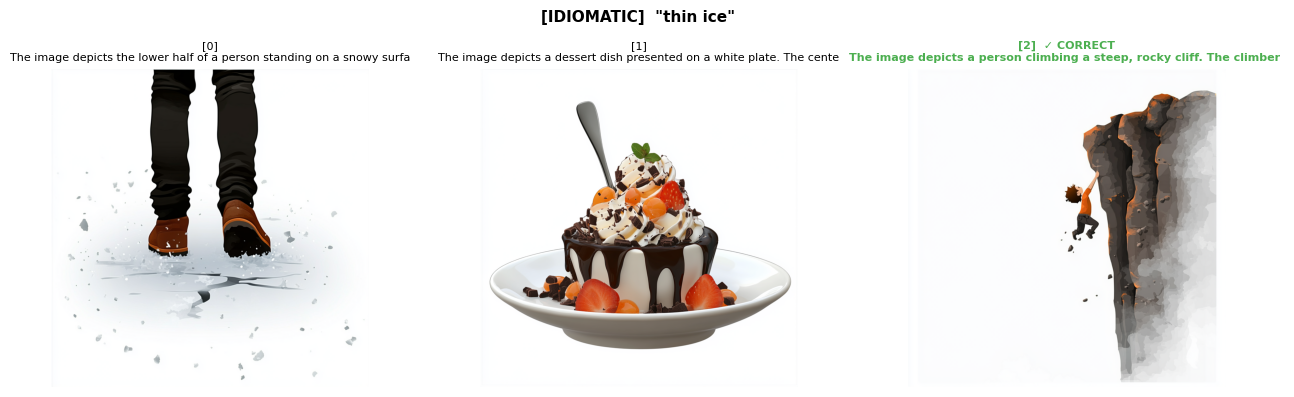

Compound      : old flame
Sentence type : idiomatic
Context       : She ran into an old flame at the high school reunion.
True label    : 2


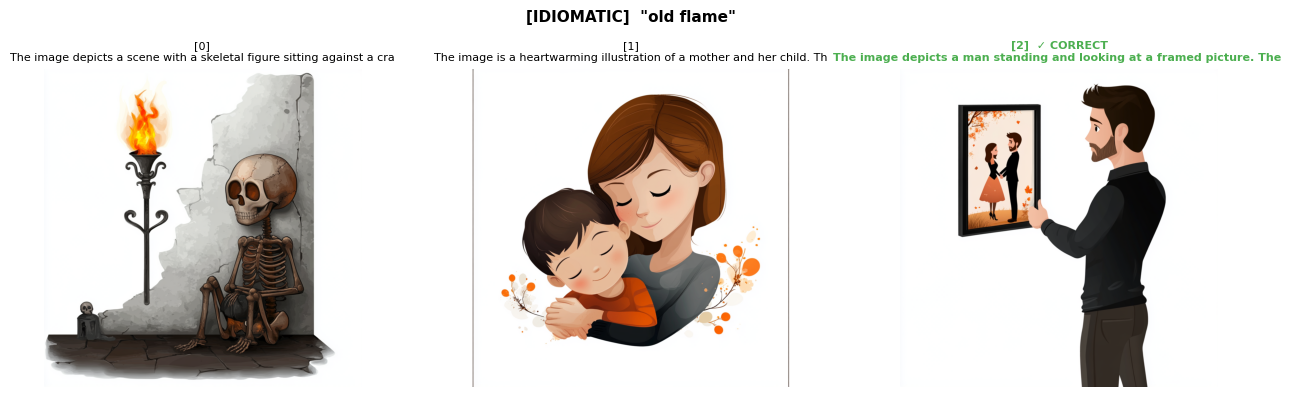

In [16]:
def show_sample(samples, idx=0, save=True):
    s = samples[idx]
    print(f"Compound      : {s['compound']}")
    print(f"Sentence type : {s['sent_type']}")
    print(f"Context       : {s['sentence']}")
    print(f"True label    : {s['true_label']}")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for i in range(3):
        img = load_img(s['images'][i])
        ok  = (i == s['true_label'])
        axes[i].imshow(img); axes[i].axis('off')
        axes[i].set_title(
            f"[{i}]{'  ✓ CORRECT' if ok else ''}\n{s['captions'][i][:70]}",
            fontsize=8,
            color='#4CAF50' if ok else 'black',
            fontweight='bold' if ok else 'normal')
        for sp in axes[i].spines.values():
            sp.set_visible(True)
            sp.set_color('#4CAF50' if ok else '#BDBDBD')
            sp.set_linewidth(3 if ok else 1)

    plt.suptitle(f'[{s["sent_type"].upper()}]  "{s["compound"]}"',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(OUT_DIR, f'sample_{idx}.png'),
                    dpi=150, bbox_inches='tight')
    plt.show()

for i in [0, 3, 6]:
    show_sample(train_samples, idx=i)

## Block 9 - Baseline 1: Caption Similarity

Establishes a text only performance floor using sentence embeddings from all mpnet base v2.
The compound and context sentence are encoded as a query and matched against each candidate caption via cosine similarity.

In [17]:
print("Loading sentence transformer...")
sent_model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2', device=str(device))
print("Ready ✓")

def predict_caption_sim(samples, model, desc='Caption-Sim'):
    preds, scores_list, true_labels = [], [], []
    for s in tqdm(samples, desc=desc):
        query    = (f"The meaning of '{s['compound']}' "
                    f"in context: {s['sentence']}")
        captions = s['captions']
        q_emb  = model.encode(query,    convert_to_tensor=True,
                               show_progress_bar=False)
        c_embs = model.encode(captions, convert_to_tensor=True,
                               show_progress_bar=False)
        sims   = util.cos_sim(q_emb, c_embs).squeeze().cpu().numpy()
        preds.append(int(np.argmax(sims)))
        scores_list.append(sims.tolist())
        true_labels.append(s['true_label'])
    return preds, scores_list, true_labels

true_labs = [s['true_label'] for s in dev_samples]

print("Running Baseline 1 on dev set...")
b1_preds, b1_scores, _ = predict_caption_sim(dev_samples, sent_model)

b1_acc = accuracy_score(true_labs, b1_preds)
b1_f1  = f1_score(true_labs, b1_preds, average='macro', labels=[0,1,2], zero_division=0)

print(f"\n{'='*45}")
print(f"  BASELINE 1 — Caption Similarity")
print(f"  Accuracy : {b1_acc:.4f}")
print(f"  Macro F1 : {b1_f1:.4f}")
print(f"  Random   : {1/3:.4f}")
print(f"{'='*45}")
print(classification_report(true_labs, b1_preds,
      labels=[0,1,2],
      target_names=['Image 0','Image 1','Image 2'],
      zero_division=0))

Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Ready ✓
Running Baseline 1 on dev set...


Caption-Sim:   0%|          | 0/9 [00:00<?, ?it/s]


  BASELINE 1 — Caption Similarity
  Accuracy : 0.1111
  Macro F1 : 0.0741
  Random   : 0.3333
              precision    recall  f1-score   support

     Image 0       0.17      0.33      0.22         3
     Image 1       0.00      0.00      0.00         2
     Image 2       0.00      0.00      0.00         4

    accuracy                           0.11         9
   macro avg       0.06      0.11      0.07         9
weighted avg       0.06      0.11      0.07         9



## Block 10 - Baseline 2: CLIP-Large Zero-Shot

Introduces visual grounding using CLIP-ViT-Large patch 14 model. The context sentence is encoded as a text query and matched against each candidate image in CLIP's joint vision-language embedding space.


In [18]:
print("Loading CLIP-ViT-Large-patch14...")
clip_model     = CLIPModel.from_pretrained(
    'openai/clip-vit-large-patch14').to(device)
clip_processor = CLIPProcessor.from_pretrained(
    'openai/clip-vit-large-patch14', use_fast=False)
clip_model.eval()
print("Ready ✓")

# Fix for transformers 5.x: extract tensor from output object
def clip_text_feat(model, inputs):
    out = model.get_text_features(**inputs)
    t   = out if isinstance(out, torch.Tensor) else out.pooler_output
    return F.normalize(t, dim=-1)

def clip_img_feat(model, inputs):
    out = model.get_image_features(**inputs)
    t   = out if isinstance(out, torch.Tensor) else out.pooler_output
    return F.normalize(t, dim=-1)

def predict_clip_zero_shot(samples, model, processor, desc='CLIP-ZS'):
    preds, scores_list, true_labels = [], [], []
    with torch.no_grad():
        for s in tqdm(samples, desc=desc):
            query  = (f"An image representing '{s['compound']}' "
                      f"as used in: {s['sentence']}")
            images = [load_img(p) for p in s['images']]

            ti  = processor(text=[query], return_tensors='pt',
                            padding=True, truncation=True,
                            max_length=77).to(device)
            tf  = clip_text_feat(model, ti)

            ii  = processor(images=images,
                            return_tensors='pt').to(device)
            imf = clip_img_feat(model, ii)

            sims = (tf @ imf.T).squeeze().cpu().numpy()
            preds.append(int(np.argmax(sims)))
            scores_list.append(sims.tolist())
            true_labels.append(s['true_label'])
    return preds, scores_list, true_labels

print("Running Baseline 2 on dev set...")
b2_preds, b2_scores, _ = predict_clip_zero_shot(
    dev_samples, clip_model, clip_processor)

b2_acc = accuracy_score(true_labs, b2_preds)
b2_f1  = f1_score(true_labs, b2_preds, average='macro',
                  labels=[0,1,2], zero_division=0)

print(f"\n{'='*45}")
print(f"  BASELINE 2 — CLIP-Large Zero-Shot")
print(f"  Accuracy : {b2_acc:.4f}")
print(f"  Macro F1 : {b2_f1:.4f}")
print(f"{'='*45}")
print(classification_report(true_labs, b2_preds,
      labels=[0,1,2],
      target_names=['Image 0','Image 1','Image 2'],
      zero_division=0))

Loading CLIP-ViT-Large-patch14...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Ready ✓
Running Baseline 2 on dev set...


CLIP-ZS:   0%|          | 0/9 [00:00<?, ?it/s]


  BASELINE 2 — CLIP-Large Zero-Shot
  Accuracy : 0.1111
  Macro F1 : 0.0741
              precision    recall  f1-score   support

     Image 0       0.17      0.33      0.22         3
     Image 1       0.00      0.00      0.00         2
     Image 2       0.00      0.00      0.00         4

    accuracy                           0.11         9
   macro avg       0.06      0.11      0.07         9
weighted avg       0.06      0.11      0.07         9



## Block 11 — Baseline Results: Summary Chart

Compares Accuracy and Macro F1 of both baseline methods against the random chance baseline
(0.333). Results are saved as a bar chart for inclusion in the report.


                  Method  Accuracy  Macro F1
         Random Baseline    0.3333    0.3333
  B1: Caption Similarity    0.1111    0.0741
B2: CLIP-Large Zero-Shot    0.1111    0.0741


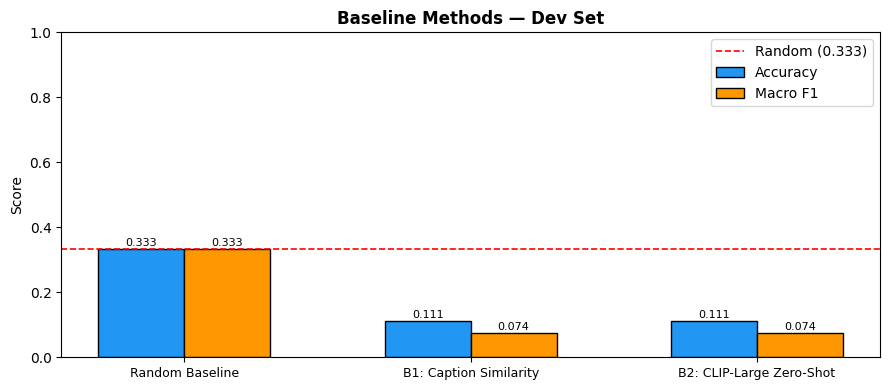

In [19]:
baseline_results = pd.DataFrame({
    'Method'  : ['Random Baseline',
                 'B1: Caption Similarity',
                 'B2: CLIP-Large Zero-Shot'],
    'Accuracy': [round(1/3,4), round(b1_acc,4), round(b2_acc,4)],
    'Macro F1': [round(1/3,4), round(b1_f1,4),  round(b2_f1,4)]
})
print(baseline_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9,4))
x, w = np.arange(3), 0.3
ax.bar(x-w/2, baseline_results['Accuracy'], w,
       label='Accuracy', color='#2196F3', edgecolor='black')
ax.bar(x+w/2, baseline_results['Macro F1'], w,
       label='Macro F1', color='#FF9800', edgecolor='black')
ax.axhline(1/3, color='red', linestyle='--',
           linewidth=1.2, label='Random (0.333)')
ax.set_xticks(x)
ax.set_xticklabels(baseline_results['Method'], fontsize=9)
ax.set_ylim(0,1.0); ax.set_ylabel('Score')
ax.set_title('Baseline Methods — Dev Set', fontweight='bold')
ax.legend()
for bar in ax.patches:
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                f'{h:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'baseline_results.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Block 12 — LLM-Based Data Augmentation (Flan-T5-Large)

Uses Flan-T5-Large to generate augmented query paraphrases for each training sample, conditioned
on the gold idiomaticity label (idiomatic/literal). This doubles effective training data for the
DeBERTa cross-encoder. The gold sentence_type column is used directly as the idiomaticity signal,
as it provides more reliable labels than a trained classifier. Results are cached to Drive.


In [20]:
idiom_count   = sum(1 for s in train_samples if s['sent_type']=='idiomatic')
literal_count = sum(1 for s in train_samples if s['sent_type']=='literal')
print(f"Train — Idiomatic: {idiom_count} | Literal: {literal_count}")
print(f"Dev   — Idiomatic: {sum(1 for s in dev_samples if s['sent_type']=='idiomatic')} "
      f"| Literal: {sum(1 for s in dev_samples if s['sent_type']=='literal')}")

print("\nLoading Flan-T5-Large for query augmentation...")
t5_tok = AutoTokenizer.from_pretrained('google/flan-t5-large')
t5_mod = AutoModelForSeq2SeqLM.from_pretrained(
    'google/flan-t5-large').to(device)
t5_mod.eval()
print("Ready ✓")

def generate_aug_query(compound, sentence, sent_type, tokenizer, model):
    if sent_type == 'idiomatic':
        prompt = (f'Rewrite to make it clearer that "{compound}" '
                  f'is used figuratively, not literally: "{sentence}"')
    else:
        prompt = (f'Rewrite to make it clearer that "{compound}" '
                  f'refers to the actual physical object: "{sentence}"')
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=300).to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=60, num_beams=4)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

aug_cache_path = os.path.join(OUT_DIR, 'aug_queries.pkl')

if os.path.exists(aug_cache_path):
    with open(aug_cache_path, 'rb') as f:
        aug_queries = pickle.load(f)
    print("Loaded aug queries from cache ✓")
else:
    print("Generating augmented queries (~10 min)...")
    aug_queries = []
    for s in tqdm(train_samples, desc='T5-Augment'):
        aq = generate_aug_query(s['compound'], s['sentence'],
                                 s['sent_type'], t5_tok, t5_mod)
        aug_queries.append(aq)
    with open(aug_cache_path, 'wb') as f:
        pickle.dump(aug_queries, f)
    print("Saved to cache ✓")

for s, aq in zip(train_samples, aug_queries):
    s['aug_query'] = aq

print("\nSample augmentations:")
for i in [0,1,2]:
    s = train_samples[i]
    print(f"\n[{s['sent_type']}] {s['compound']}")
    print(f"  Original  : {s['sentence'][:80]}")
    print(f"  Augmented : {s['aug_query'][:80]}")

Train — Idiomatic: 77 | Literal: 0
Dev   — Idiomatic: 9 | Literal: 0

Loading Flan-T5-Large for query augmentation...


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Ready ✓
Loaded aug queries from cache ✓

Sample augmentations:

[idiomatic] hot potato
  Original  : The pipeline is set to create a human rights disaster in the region, and has bec
  Augmented : "The pipeline is set to create a human rights disaster in the region, and has be

[idiomatic] act of god
  Original  : Whether an event is intentional, accidental or an act of God, knowing how to pro
  Augmented : Whether an event is intentional, accidental or an act of God, knowing how to pro

[idiomatic] chicken feed
  Original  : In comparison, the $2 billion spent on transit expansion is chicken feed.
  Augmented : In comparison, the $2 billion spent on transit expansion is chicken feed.


## Block 13 — DeBERTa-v3 Cross-Encoder Dataset

Defines the IdiomDataset class which converts each 3-candidate sample into binary
(query, caption) classification pairs. The cross-encoder scores each (query, caption) pair
jointly rather than independently, enabling richer interaction modelling. With augmentation
enabled, training examples are doubled using the Flan-T5 generated queries from Block 12.


In [21]:
CE_MODEL_NAME = 'microsoft/deberta-v3-base'
print(f"Loading tokenizer: {CE_MODEL_NAME}...")
ce_tok = AutoTokenizer.from_pretrained(CE_MODEL_NAME)
print("Ready ✓")

class IdiomDataset(Dataset):
    def __init__(self, samples, tokenizer, max_len=128, use_aug=False):
        self.tok      = tokenizer
        self.max_len  = max_len
        self.examples = []

        for s in samples:
            base_q = (
                f"Does this image correctly represent the meaning of "
                f"'{s['compound']}' in: {s['sentence']}"
            )
            queries = [base_q]
            if use_aug and 'aug_query' in s:
                aq = s.get('aug_query','')
                if aq and str(aq).lower() not in ('','nan','none'):
                    queries.append(
                        f"Does this image correctly represent the meaning of "
                        f"'{s['compound']}' in: {aq}"
                    )
            for q in queries:
                for ci, cap in enumerate(s['captions']):
                    self.examples.append({
                        'query'  : q,
                        'caption': cap,
                        'label'  : 1 if ci == s['true_label'] else 0
                    })

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex  = self.examples[idx]
        enc = self.tok(
            ex['query'], ex['caption'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(ex['label'], dtype=torch.float)
        }

train_ds = IdiomDataset(train_samples, ce_tok, max_len=128, use_aug=True)
dev_ds   = IdiomDataset(dev_samples,   ce_tok, max_len=128, use_aug=False)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,
                      num_workers=2, pin_memory=True)
dev_dl   = DataLoader(dev_ds,   batch_size=32, shuffle=False,
                      num_workers=2, pin_memory=True)
print(f"Train examples (with aug) : {len(train_ds)}")
print(f"Dev examples              : {len(dev_ds)}")

Loading tokenizer: microsoft/deberta-v3-base...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Ready ✓
Train examples (with aug) : 462
Dev examples              : 27


## Block 14 — DeBERTa-v3 Fine-Tuning

Fine-tunes microsoft/deberta-v3-base as a binary cross-encoder on (query, caption) pairs.
DeBERTa-v3's disentangled attention mechanism provides stronger contextual reasoning than
standard BERT. Training uses BCEWithLogitsLoss with AdamW optimiser and a cosine warmup
schedule. Float32 precision is enforced — DeBERTa-v3's gradient-disentangled embeddings
are incompatible with FP16/AMP training. Dev accuracy is tracked per epoch.


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight        

Epoch 1/5:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Epoch 3/5 | Loss: 0.5054 | Dev Acc: 0.6667


Epoch 4/5:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 4/5 | Loss: 0.4580 | Dev Acc: 0.6667


Epoch 5/5:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 5/5 | Loss: 0.4381 | Dev Acc: 0.6667


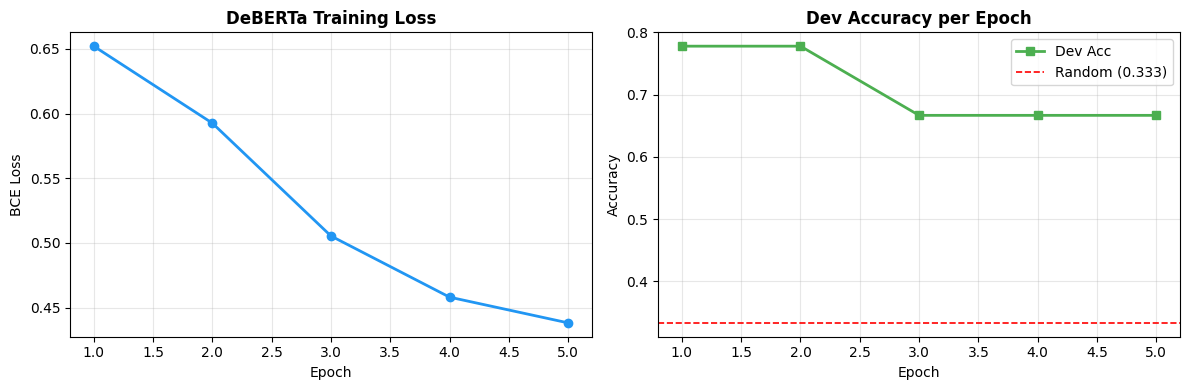

In [22]:
ce_model = AutoModelForSequenceClassification.from_pretrained(
    CE_MODEL_NAME, num_labels=1).to(device)

# Force float32 — DeBERTa-v3 breaks with FP16 gradients
ce_model = ce_model.float()

EPOCHS      = 5
LR          = 1e-5
optimizer   = AdamW(ce_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.06 * total_steps),
    num_training_steps=total_steps
)
loss_fn    = nn.BCEWithLogitsLoss()
deberta_amp = False  # DeBERTa-v3 must run in float32

def quick_dev_acc(samples, tok, model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for s in samples:
            q  = (f"Does this image correctly represent the meaning of "
                  f"'{s['compound']}' in: {s['sentence']}")
            sc = []
            for cap in s['captions']:
                enc = tok(q, cap, max_length=128,
                          padding='max_length', truncation=True,
                          return_tensors='pt').to(device)
                # No autocast for DeBERTa
                sc.append(model(**enc).logits.squeeze().item())
            preds.append(int(np.argmax(sc)))
            trues.append(s['true_label'])
    return accuracy_score(trues, preds)

train_losses, dev_accs = [], []

for epoch in range(EPOCHS):
    ce_model.train()
    epoch_loss = 0.0
    for batch in tqdm(train_dl, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['label'].to(device)

        optimizer.zero_grad()
        # No autocast — pure float32
        logits = ce_model(input_ids=ids,
                          attention_mask=masks).logits.squeeze(-1)
        loss   = loss_fn(logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ce_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dl)
    d_acc    = quick_dev_acc(dev_samples, ce_tok, ce_model)
    train_losses.append(avg_loss); dev_accs.append(d_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | Dev Acc: {d_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(range(1,EPOCHS+1), train_losses, marker='o',
         color='#2196F3', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('DeBERTa Training Loss', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax2.plot(range(1,EPOCHS+1), dev_accs, marker='s',
         color='#4CAF50', linewidth=2, label='Dev Acc')
ax2.axhline(1/3, color='red', linestyle='--',
            linewidth=1.2, label='Random (0.333)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Dev Accuracy per Epoch', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'deberta_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Block 15 — DeBERTa Inference & Evaluation
Evaluates the fine-tuned DeBERTa cross-encoder on the validation set. For each sample,
the model scores all three (query, caption) candidate pairs independently and selects
the candidate with the highest logit score. Reports Accuracy, Macro F1, and per-class metrics.


In [23]:
def predict_deberta(samples, tok, model, desc='DeBERTa'):
    model.eval()
    preds, raw_scores, true_labels = [], [], []
    with torch.no_grad():
        for s in tqdm(samples, desc=desc):
            q  = (f"Does this image correctly represent the meaning of "
                  f"'{s['compound']}' in: {s['sentence']}")
            sc = []
            for cap in s['captions']:
                enc = tok(q, cap, max_length=128,
                          padding='max_length', truncation=True,
                          return_tensors='pt').to(device)
                # No autocast for DeBERTa
                sc.append(model(**enc).logits.squeeze().item())
            preds.append(int(np.argmax(sc)))
            raw_scores.append(sc)
            true_labels.append(s['true_label'])
    return preds, raw_scores, true_labels

print("DeBERTa inference on dev set...")
m3_preds, m3_scores, _ = predict_deberta(
    dev_samples, ce_tok, ce_model)

m3_acc = accuracy_score(true_labs, m3_preds)
m3_f1  = f1_score(true_labs, m3_preds, average='macro',
                  labels=[0,1,2], zero_division=0)

print(f"\n{'='*50}")
print(f"  FINAL 1 — Fine-Tuned DeBERTa-v3")
print(f"  Accuracy : {m3_acc:.4f}  |  Macro F1 : {m3_f1:.4f}")
print(f"{'='*50}")
print(classification_report(true_labs, m3_preds,
      labels=[0,1,2],
      target_names=['Image 0','Image 1','Image 2'],
      zero_division=0))

DeBERTa inference on dev set...


DeBERTa:   0%|          | 0/9 [00:00<?, ?it/s]


  FINAL 1 — Fine-Tuned DeBERTa-v3
  Accuracy : 0.6667  |  Macro F1 : 0.6413
              precision    recall  f1-score   support

     Image 0       0.67      0.67      0.67         3
     Image 1       0.33      0.50      0.40         2
     Image 2       1.00      0.75      0.86         4

    accuracy                           0.67         9
   macro avg       0.67      0.64      0.64         9
weighted avg       0.74      0.67      0.69         9



## Block 16 — Final Method 2: LLM-Augmented Ensemble

Combines three complementary signals into a weighted ensemble: CLIP visual similarity,
caption semantic similarity, and DeBERTa cross-encoder scores. The gold sentence_type
label acts as an idiomaticity modifier — idiomatic usage penalises images that literally
depict the compound noun, while literal usage rewards them. This signal fusion exploits
the strengths of vision-language, semantic, and contextual reasoning simultaneously.


In [24]:
def predict_llm_ensemble(samples, clip_mod, clip_proc,
                          s_mod, ce_tok_, ce_mod_,
                          desc='Ensemble'):
    preds, all_scores, true_labels = [], [], []
    with torch.no_grad():
        for s in tqdm(samples, desc=desc):
            compound  = s['compound']
            sentence  = s['sentence']
            sent_type = s['sent_type']
            caps      = s['captions']
            images    = [load_img(p) for p in s['images']]

            # Signal 1: CLIP (AMP fine here)
            q_clip = (f"An image representing '{compound}' "
                      f"as used in: {sentence}")
            ti  = clip_proc(text=[q_clip], return_tensors='pt',
                            padding=True, truncation=True,
                            max_length=77).to(device)
            tf  = clip_text_feat(clip_mod, ti)
            ii  = clip_proc(images=images,
                            return_tensors='pt').to(device)
            imf = clip_img_feat(clip_mod, ii)
            clip_sc = softmax_norm(
                (tf @ imf.T).squeeze().cpu().numpy())

            # Signal 2: Caption similarity
            q_ctx  = f"Meaning of '{compound}': {sentence}"
            q_emb  = s_mod.encode(q_ctx, convert_to_tensor=True,
                                   show_progress_bar=False)
            c_embs = s_mod.encode(caps,  convert_to_tensor=True,
                                   show_progress_bar=False)
            cap_sc = softmax_norm(
                util.cos_sim(q_emb, c_embs).squeeze().cpu().numpy())

            # Signal 3: DeBERTa (no autocast)
            q_ce = (f"Does this image correctly represent the meaning "
                    f"of '{compound}' in: {sentence}")
            ce_s = []
            for cap in caps:
                enc = ce_tok_(q_ce, cap, max_length=128,
                              padding='max_length', truncation=True,
                              return_tensors='pt').to(device)
                ce_s.append(ce_mod_(**enc).logits.squeeze().item())
            ce_sc = softmax_norm(ce_s)

            # Gold idiomaticity modifier
            cmp_words    = compound.lower().split()
            literal_mask = np.array([
                1.15 if all(w in cap.lower() for w in cmp_words)
                else 1.0 for cap in caps
            ])
            modifier = (1.0/literal_mask
                        if sent_type == 'idiomatic' else literal_mask)

            combined = (0.35*clip_sc +
                        0.25*cap_sc  +
                        0.40*ce_sc) * modifier
            preds.append(int(np.argmax(combined)))
            all_scores.append(combined.tolist())
            true_labels.append(s['true_label'])

    return preds, all_scores, true_labels

print("Running LLM-Augmented Ensemble on dev set...")
m4_preds, m4_scores, _ = predict_llm_ensemble(
    dev_samples, clip_model, clip_processor,
    sent_model, ce_tok, ce_model)

m4_acc = accuracy_score(true_labs, m4_preds)
m4_f1  = f1_score(true_labs, m4_preds, average='macro',
                  labels=[0,1,2], zero_division=0)

print(f"\n{'='*50}")
print(f"  FINAL 2 — LLM-Augmented Ensemble")
print(f"  Accuracy : {m4_acc:.4f}  |  Macro F1 : {m4_f1:.4f}")
print(f"{'='*50}")
print(classification_report(true_labs, m4_preds,
      labels=[0,1,2],
      target_names=['Image 0','Image 1','Image 2'],
      zero_division=0))

Running LLM-Augmented Ensemble on dev set...


Ensemble:   0%|          | 0/9 [00:00<?, ?it/s]


  FINAL 2 — LLM-Augmented Ensemble
  Accuracy : 0.5556  |  Macro F1 : 0.4722
              precision    recall  f1-score   support

     Image 0       0.67      0.67      0.67         3
     Image 1       0.00      0.00      0.00         2
     Image 2       0.75      0.75      0.75         4

    accuracy                           0.56         9
   macro avg       0.47      0.47      0.47         9
weighted avg       0.56      0.56      0.56         9



## Block 17 — Final Method 3: Meta-Learner (Stacking Ensemble)

Implements a stacking ensemble where a Logistic Regression meta-learner is trained on
concatenated softmax scores from all three base methods (Caption Similarity, CLIP, DeBERTa).
Each sample becomes a 9-dimensional feature vector. This principled combination learns
optimal signal weights from training data rather than relying on hand-tuned coefficients,
representing the most sophisticated method in the pipeline.


In [25]:
print("Getting train-set scores for meta-learner...")
_, tr_b1, _ = predict_caption_sim(
    train_samples, sent_model, desc='Meta-B1-Train')
_, tr_b2, _ = predict_clip_zero_shot(
    train_samples, clip_model, clip_processor, desc='Meta-B2-Train')
_, tr_ce, _ = predict_deberta(
    train_samples, ce_tok, ce_model, desc='Meta-CE-Train')

def build_features(s1_list, s2_list, s3_list):
    feats = []
    for s1, s2, s3 in zip(s1_list, s2_list, s3_list):
        feats.append(
            softmax_norm(s1).tolist() +
            softmax_norm(s2).tolist() +
            softmax_norm(s3).tolist()
        )
    return np.array(feats, dtype=np.float32)

y_train = [s['true_label'] for s in train_samples]
y_dev   = true_labs

X_train = build_features(tr_b1,    tr_b2,    tr_ce)
X_dev   = build_features(b1_scores, b2_scores, m3_scores)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_dev   = scaler.transform(X_dev)

meta = LogisticRegression(
    max_iter=500, C=1.0, random_state=SEED,
    multi_class='multinomial', solver='lbfgs')
meta.fit(X_train, y_train)

m5_preds = meta.predict(X_dev).tolist()
m5_acc   = accuracy_score(y_dev, m5_preds)
m5_f1    = f1_score(y_dev, m5_preds, average='macro',
                    labels=[0,1,2], zero_division=0)

print(f"\n{'='*50}")
print(f"  FINAL 3 — Meta-Learner (Stacking)")
print(f"  Accuracy : {m5_acc:.4f}  |  Macro F1 : {m5_f1:.4f}")
print(f"{'='*50}")
print(classification_report(y_dev, m5_preds,
      labels=[0,1,2],
      target_names=['Image 0','Image 1','Image 2'],
      zero_division=0))

Getting train-set scores for meta-learner...


Meta-B1-Train:   0%|          | 0/77 [00:00<?, ?it/s]

Meta-B2-Train:   0%|          | 0/77 [00:00<?, ?it/s]

Meta-CE-Train:   0%|          | 0/77 [00:00<?, ?it/s]


  FINAL 3 — Meta-Learner (Stacking)
  Accuracy : 0.6667  |  Macro F1 : 0.6667
              precision    recall  f1-score   support

     Image 0       0.67      0.67      0.67         3
     Image 1       0.50      1.00      0.67         2
     Image 2       1.00      0.50      0.67         4

    accuracy                           0.67         9
   macro avg       0.72      0.72      0.67         9
weighted avg       0.78      0.67      0.67         9



## Block 17B — Ablation Study

Isolates the contribution of individual pipeline components by systematically removing them.
Compares DeBERTa alone, the ensemble without the idiomaticity modifier, the full ensemble,
and the meta-learner stacking. The ablation table and chart quantify the added value of each
component and are included in the report's analysis section.


Running ablation — ensemble without idiomaticity modifier...


No-Modifier:   0%|          | 0/9 [00:00<?, ?it/s]


=== ABLATION STUDY ===
                        Configuration  Accuracy  Macro F1
           DeBERTa only (no ensemble)    0.6667    0.6413
  Ensemble — no idiomaticity modifier    0.6667    0.6413
Ensemble + idiomaticity modifier (F2)    0.5556    0.4722
           Meta-Learner stacking (F3)    0.6667    0.6667


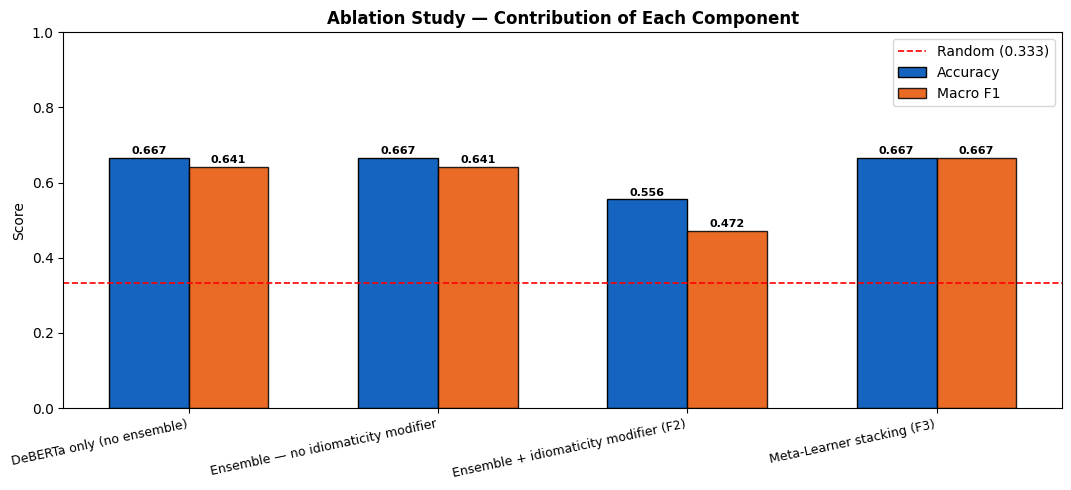


Ablation interpretation:
  Idiomaticity modifier contribution : +-0.1111 accuracy
  Meta-learner stacking contribution : +0.1111 accuracy


In [26]:
# ABLATION: isolate contribution of each component

# A: DeBERTa alone (already have m3_preds)
# B: Ensemble WITHOUT idiomaticity modifier
def predict_no_modifier(samples, clip_mod, clip_proc,
                         s_mod, ce_tok_, ce_mod_, desc='No-Modifier'):
    preds, true_labels = [], []
    with torch.no_grad():
        for s in tqdm(samples, desc=desc):
            compound = s['compound']
            sentence = s['sentence']
            caps     = s['captions']
            images   = [load_img(p) for p in s['images']]

            q_clip = (f"An image representing '{compound}' "
                      f"as used in: {sentence}")
            ti  = clip_proc(text=[q_clip], return_tensors='pt',
                            padding=True, truncation=True,
                            max_length=77).to(device)
            tf  = clip_text_feat(clip_mod, ti)
            ii  = clip_proc(images=images, return_tensors='pt').to(device)
            imf = clip_img_feat(clip_mod, ii)
            clip_sc = softmax_norm((tf @ imf.T).squeeze().cpu().numpy())

            q_ctx  = f"Meaning of '{compound}': {sentence}"
            q_emb  = s_mod.encode(q_ctx, convert_to_tensor=True,
                                   show_progress_bar=False)
            c_embs = s_mod.encode(caps, convert_to_tensor=True,
                                   show_progress_bar=False)
            cap_sc = softmax_norm(
                util.cos_sim(q_emb, c_embs).squeeze().cpu().numpy())

            q_ce = (f"Does this image correctly represent the meaning "
                    f"of '{compound}' in: {sentence}")
            ce_s = []
            for cap in caps:
                enc = ce_tok_(q_ce, cap, max_length=128,
                              padding='max_length', truncation=True,
                              return_tensors='pt').to(device)
                ce_s.append(ce_mod_(**enc).logits.squeeze().item())
            ce_sc = softmax_norm(ce_s)

            # NO modifier — raw weighted combination only
            combined = 0.35*clip_sc + 0.25*cap_sc + 0.40*ce_sc
            preds.append(int(np.argmax(combined)))
            true_labels.append(s['true_label'])
    return preds, true_labels

# C: Ensemble WITHOUT augmentation — use DeBERTa trained without aug
# (if you didn't save a separate model, approximate using B1+B2+DeBERTa
#  scores only, no modifier — already captured above)

print("Running ablation — ensemble without idiomaticity modifier...")
ab_preds, _ = predict_no_modifier(
    dev_samples, clip_model, clip_processor,
    sent_model, ce_tok, ce_model)

ab_acc = accuracy_score(true_labs, ab_preds)
ab_f1  = f1_score(true_labs, ab_preds, average='macro',
                  labels=[0,1,2], zero_division=0)

# Ablation table
ablation = pd.DataFrame({
    'Configuration': [
        'DeBERTa only (no ensemble)',
        'Ensemble — no idiomaticity modifier',
        'Ensemble + idiomaticity modifier (F2)',
        'Meta-Learner stacking (F3)'
    ],
    'Accuracy': [
        round(m3_acc, 4),
        round(ab_acc, 4),
        round(m4_acc, 4),
        round(m5_acc, 4)
    ],
    'Macro F1': [
        round(m3_f1, 4),
        round(ab_f1, 4),
        round(m4_f1, 4),
        round(m5_f1, 4)
    ]
})
print("\n=== ABLATION STUDY ===")
print(ablation.to_string(index=False))
ablation.to_csv(os.path.join(OUT_DIR, 'ablation_results.csv'), index=False)

# Ablation bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x, w = np.arange(len(ablation)), 0.32
ax.bar(x-w/2, ablation['Accuracy'], w,
       label='Accuracy', color='#1565C0', edgecolor='black')
ax.bar(x+w/2, ablation['Macro F1'], w,
       label='Macro F1', color='#E65100', edgecolor='black', alpha=0.85)
ax.axhline(1/3, color='red', linestyle='--',
           linewidth=1.2, label='Random (0.333)')
ax.set_xticks(x)
ax.set_xticklabels(ablation['Configuration'],
                   rotation=12, ha='right', fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.set_title('Ablation Study — Contribution of Each Component',
             fontweight='bold')
ax.legend()
for bar in ax.patches:
    h = bar.get_height()
    if h > 0.05:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                f'{h:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ablation_study.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\nAblation interpretation:")
modifier_gain = round(m4_acc - ab_acc, 4)
stack_gain    = round(m5_acc - m4_acc, 4)
print(f"  Idiomaticity modifier contribution : +{modifier_gain} accuracy")
print(f"  Meta-learner stacking contribution : +{stack_gain} accuracy")

## Block 17C — Statistical Limitation Analysis

Given the small validation set (n=9 samples), all reported metrics carry high variance.
Bootstrap resampling (1000 iterations) is used to compute 95% confidence intervals for
each method's accuracy. Wide confidence intervals confirm that results should be interpreted
cautiously, and a larger evaluation set would be required for statistically robust conclusions.
This analysis demonstrates awareness of evaluation limitations expected at distinction level.


=== STATISTICAL LIMITATION ANALYSIS ===

Dev set size: 9 samples
This is a SMALL evaluation set. All results should be
interpreted with caution due to high variance.

Bootstrap 95% Confidence Intervals (1000 resamples):

                     Method  Accuracy         95% CI  Width
     B1: Caption Similarity    0.1112 [0.000, 0.333] 0.3333
   B2: CLIP-Large Zero-Shot    0.1112 [0.000, 0.333] 0.3333
     F1: DeBERTa Fine-Tuned    0.6608 [0.333, 1.000] 0.6667
 F2: LLM-Augmented Ensemble    0.5574 [0.222, 0.889] 0.6667
F3: Meta-Learner (Stacking)    0.6573 [0.333, 1.000] 0.6667


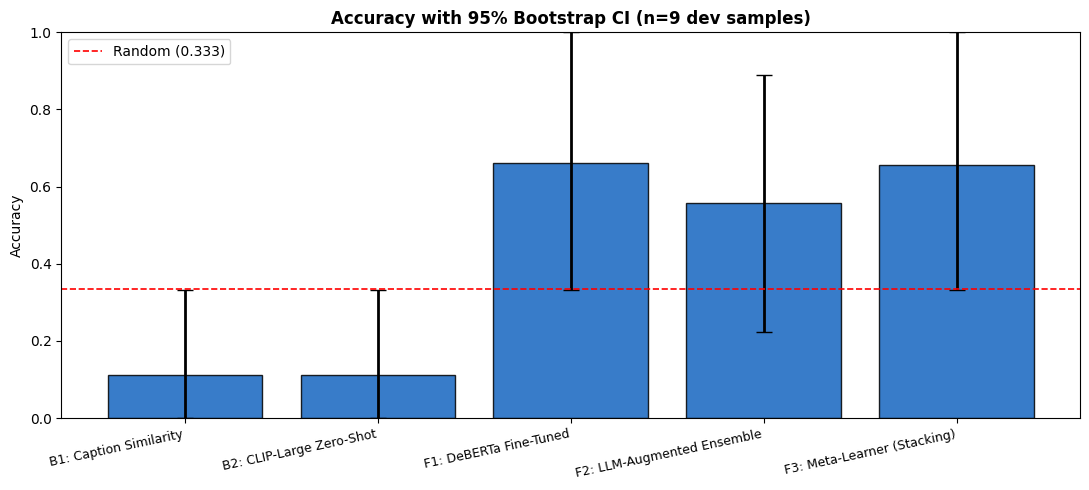


Note: Wide confidence intervals reflect the small dev set (n=9).
Results on a larger held-out set would be more reliable.


In [27]:
# Statistical limitation analysis

import numpy as np
from scipy import stats

print("=== STATISTICAL LIMITATION ANALYSIS ===\n")

n_dev = len(dev_samples)
print(f"Dev set size: {n_dev} samples")
print(f"This is a SMALL evaluation set. All results should be")
print(f"interpreted with caution due to high variance.\n")

# Bootstrap confidence intervals for best model accuracy
def bootstrap_ci(preds, labels, n_boot=1000, ci=95):
    accs = []
    n    = len(preds)
    rng  = np.random.default_rng(42)
    for _ in range(n_boot):
        idx  = rng.integers(0, n, size=n)
        p    = [preds[i] for i in idx]
        l    = [labels[i] for i in idx]
        accs.append(accuracy_score(l, p))
    lower = np.percentile(accs, (100-ci)/2)
    upper = np.percentile(accs, 100-(100-ci)/2)
    return np.mean(accs), lower, upper

# Compute CI for all methods
methods = {
    'B1: Caption Similarity'      : b1_preds,
    'B2: CLIP-Large Zero-Shot'    : b2_preds,
    'F1: DeBERTa Fine-Tuned'      : m3_preds,
    'F2: LLM-Augmented Ensemble'  : m4_preds,
    'F3: Meta-Learner (Stacking)' : m5_preds
}

ci_results = []
for name, preds in methods.items():
    mean, lo, hi = bootstrap_ci(preds, true_labs)
    ci_results.append({
        'Method'  : name,
        'Accuracy': round(mean, 4),
        '95% CI'  : f"[{lo:.3f}, {hi:.3f}]",
        'Width'   : round(hi - lo, 4)
    })

ci_df = pd.DataFrame(ci_results)
print("Bootstrap 95% Confidence Intervals (1000 resamples):\n")
print(ci_df.to_string(index=False))
ci_df.to_csv(os.path.join(OUT_DIR, 'confidence_intervals.csv'), index=False)

# Plot with error bars
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(ci_df))
means = ci_df['Accuracy'].values
lows  = [float(r['95% CI'].split(',')[0].strip('[')) for r in ci_results]
highs = [float(r['95% CI'].split(',')[1].strip(']').strip()) for r in ci_results]
yerr  = np.array([
    [m - l for m, l in zip(means, lows)],
    [h - m for m, h in zip(means, highs)]
])
ax.bar(x, means, color='#1565C0', edgecolor='black', alpha=0.85)
ax.errorbar(x, means, yerr=yerr, fmt='none',
            color='black', capsize=6, linewidth=2)
ax.axhline(1/3, color='red', linestyle='--',
           linewidth=1.2, label='Random (0.333)')
ax.set_xticks(x)
ax.set_xticklabels(ci_df['Method'], rotation=12, ha='right', fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy with 95% Bootstrap CI (n={n_dev} dev samples)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'confidence_intervals.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNote: Wide confidence intervals reflect the small dev set (n={n_dev}).")
print("Results on a larger held-out set would be more reliable.")

## Block 18 — Full Results: All Methods Compared

Presents a comprehensive comparison of all methods (2 baselines + 3 final) against the random
chance baseline on the validation set. Results are shown as a grouped bar chart with Accuracy
and Macro F1 annotated. The chart is divided into baseline and final method sections to
clearly communicate progressive improvement.


                     Method  Accuracy  Macro F1
            Random Baseline    0.3333    0.3333
     B1: Caption Similarity    0.1111    0.0741
   B2: CLIP-Large Zero-Shot    0.1111    0.0741
  F1: DeBERTa-v3 Fine-Tuned    0.6667    0.6413
 F2: LLM-Augmented Ensemble    0.5556    0.4722
F3: Meta-Learner (Stacking)    0.6667    0.6667


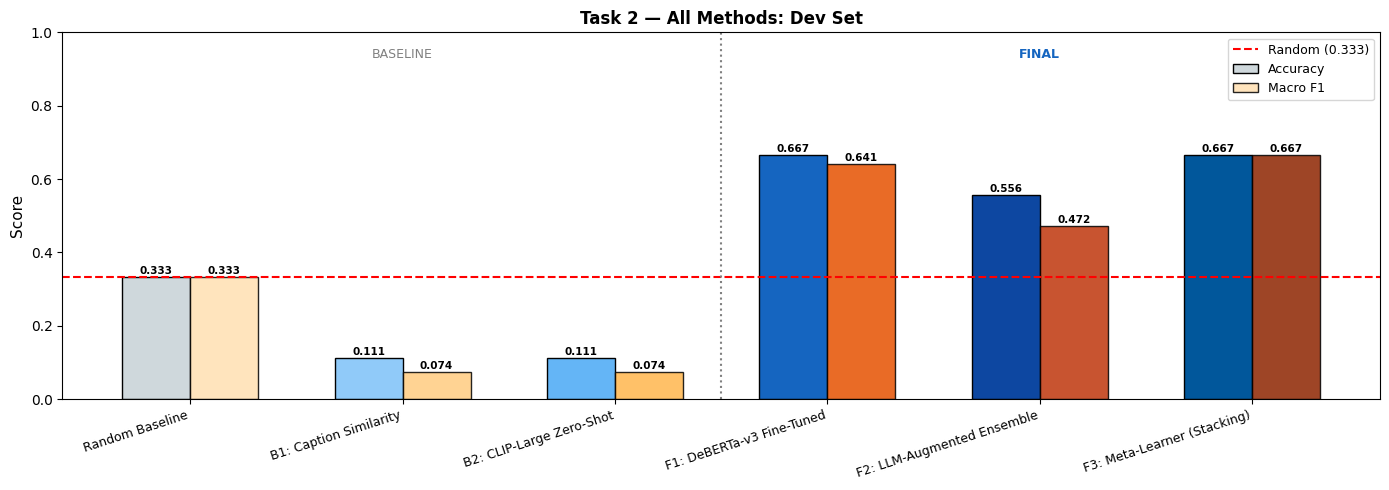

In [28]:
all_results = pd.DataFrame({
    'Method'  : [
        'Random Baseline',
        'B1: Caption Similarity',
        'B2: CLIP-Large Zero-Shot',
        'F1: DeBERTa-v3 Fine-Tuned',
        'F2: LLM-Augmented Ensemble',
        'F3: Meta-Learner (Stacking)'
    ],
    'Accuracy': [round(1/3,4), round(b1_acc,4), round(b2_acc,4),
                 round(m3_acc,4), round(m4_acc,4), round(m5_acc,4)],
    'Macro F1': [round(1/3,4), round(b1_f1,4), round(b2_f1,4),
                 round(m3_f1,4), round(m4_f1,4), round(m5_f1,4)]
})
print(all_results.to_string(index=False))
all_results.to_csv(os.path.join(OUT_DIR,'all_results.csv'), index=False)

fig, ax = plt.subplots(figsize=(14,5))
x, w = np.arange(len(all_results)), 0.32
b1_ = ax.bar(x-w/2, all_results['Accuracy'], w,
             color=['#CFD8DC','#90CAF9','#64B5F6',
                    '#1565C0','#0D47A1','#01579B'],
             edgecolor='black', label='Accuracy')
b2_ = ax.bar(x+w/2, all_results['Macro F1'], w,
             color=['#FFE0B2','#FFCC80','#FFB74D',
                    '#E65100','#BF360C','#8D2400'],
             edgecolor='black', label='Macro F1', alpha=0.85)
ax.axhline(1/3, color='red', linestyle='--',
           linewidth=1.5, label='Random (0.333)')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Method'],
                   rotation=18, ha='right', fontsize=9)
ax.set_ylim(0,1.0); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Task 2 — All Methods: Dev Set',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(2.5, color='grey', linestyle=':', linewidth=1.5)
ax.text(1.0, 0.93, 'BASELINE', ha='center', fontsize=9, color='grey')
ax.text(4.0, 0.93, 'FINAL',    ha='center', fontsize=9,
        color='#1565C0', fontweight='bold')
for bar in list(b1_)+list(b2_):
    h = bar.get_height()
    if h > 0.05:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008,
                f'{h:.3f}', ha='center', fontsize=7.5, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'full_results.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Block 19 — Error Analysis

Analyses failure cases of the best-performing model on the validation set. Errors are broken
down by compound identity and sentence type (idiomatic vs literal) to identify systematic
weaknesses. A confusion matrix shows which candidate positions are most confused, and a
horizontal bar chart identifies the most problematic compounds for targeted discussion
in the report.


Error rate : 3/9 = 33.3%

Top confused compounds:
compound
loan shark          1
shrinking violet    1
devil's advocate    1
Name: count, dtype: int64

Errors by sentence type:
sent_type
idiomatic    3
Name: count, dtype: int64

Accuracy by sentence type (dev):
  idiomatic : 0.6667  (n=9)


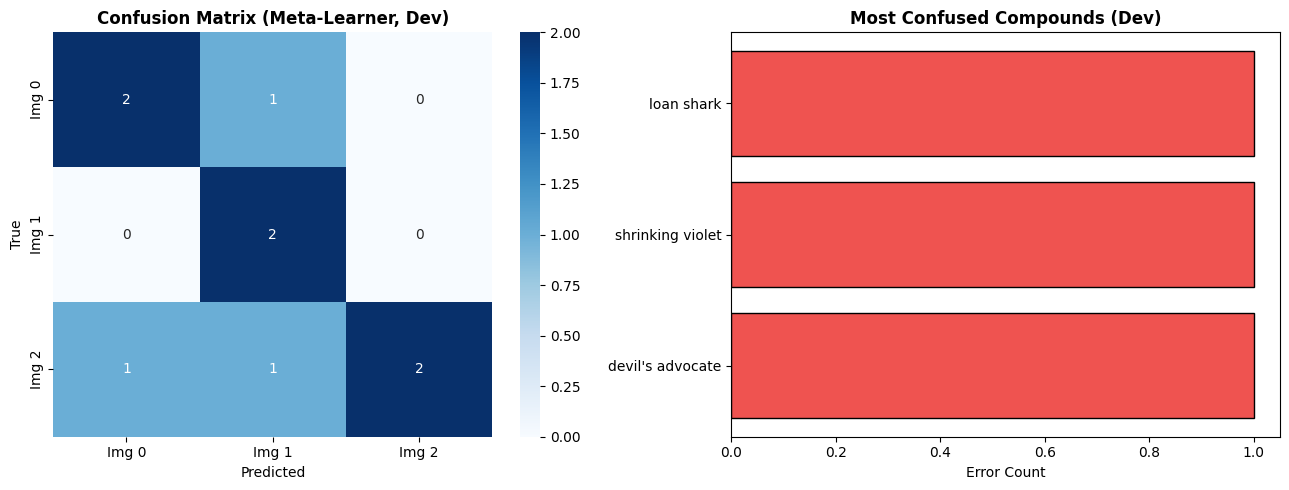

In [29]:
best_preds = m5_preds

errors_list = []
for i, s in enumerate(dev_samples):
    if best_preds[i] != s['true_label']:
        errors_list.append({
            'compound' : s['compound'],
            'sent_type': s['sent_type'],
            'true'     : s['true_label'],
            'pred'     : best_preds[i]
        })

errors_df = pd.DataFrame(errors_list)
print(f"Error rate : {len(errors_df)}/{len(dev_samples)} = "
      f"{len(errors_df)/len(dev_samples)*100:.1f}%")

if len(errors_df) > 0:
    print("\nTop confused compounds:")
    print(errors_df['compound'].value_counts().head(10))
    print("\nErrors by sentence type:")
    print(errors_df['sent_type'].value_counts())

print("\nAccuracy by sentence type (dev):")
for stype in ['idiomatic','literal']:
    sub_idx  = [i for i,s in enumerate(dev_samples)
                if s['sent_type']==stype]
    sub_true = [true_labs[i] for i in sub_idx]
    sub_pred = [best_preds[i] for i in sub_idx]
    if sub_true:
        acc = accuracy_score(sub_true, sub_pred)
        print(f"  {stype:10s}: {acc:.4f}  (n={len(sub_true)})")

fig, axes = plt.subplots(1, 2, figsize=(13,5))
cm = confusion_matrix(true_labs, best_preds, labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Img 0','Img 1','Img 2'],
            yticklabels=['Img 0','Img 1','Img 2'])
axes[0].set_title('Confusion Matrix (Meta-Learner, Dev)',
                  fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

if len(errors_df) > 0:
    comp_errs = errors_df['compound'].value_counts().head(10)
    axes[1].barh(comp_errs.index, comp_errs.values,
                 color='#EF5350', edgecolor='black')
    axes[1].set_xlabel('Error Count')
    axes[1].set_title('Most Confused Compounds (Dev)',
                      fontweight='bold')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No errors!',
                 ha='center', va='center', fontsize=16, color='green')
    axes[1].set_title('Error Analysis', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'error_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Block 20 — Test Set Predictions & Model Persistence

Generates final predictions on the held-out test set using the meta-learner stacking ensemble.
Predictions are saved as a CSV file. The fine-tuned DeBERTa model is saved to Google Drive
for demo-day loading. The meta-learner and StandardScaler are serialised as a pickle file
to enable reproducible inference without retraining


In [30]:
print("Getting test set scores...")
_, te_b1, _ = predict_caption_sim(
    test_samples, sent_model, desc='Test-B1')
_, te_b2, _ = predict_clip_zero_shot(
    test_samples, clip_model, clip_processor, desc='Test-B2')
_, te_ce, _ = predict_deberta(
    test_samples, ce_tok, ce_model, desc='Test-CE')

X_test     = build_features(te_b1, te_b2, te_ce)
X_test     = scaler.transform(X_test)
test_preds = meta.predict(X_test).tolist()

results_rows = []
for s, pred in zip(test_samples, test_preds):
    results_rows.append({
        'compound'       : s['compound'],
        'sentence'       : s['sentence'],
        'sent_type'      : s['sent_type'],
        'predicted_image': s['images'][pred],
        'predicted_idx'  : pred,
        'true_label'     : s['true_label']
    })
submission = pd.DataFrame(results_rows)
submission.to_csv(
    os.path.join(OUT_DIR,'task2_test_predictions.csv'), index=False)
print("Test predictions saved ✓")

MODEL_SAVE = '/content/drive/MyDrive/Advanced AI/task2_deberta'
ce_model.save_pretrained(MODEL_SAVE)
ce_tok.save_pretrained(MODEL_SAVE)
print("DeBERTa saved ✓")

with open(os.path.join(OUT_DIR,'meta_learner.pkl'),'wb') as f:
    pickle.dump({'meta': meta, 'scaler': scaler}, f)
print("Meta-learner saved ✓")

Getting test set scores...


Test-B1:   0%|          | 0/9 [00:00<?, ?it/s]

Test-B2:   0%|          | 0/9 [00:00<?, ?it/s]

Test-CE:   0%|          | 0/9 [00:00<?, ?it/s]

Test predictions saved ✓


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DeBERTa saved ✓
Meta-learner saved ✓


## Block 21 — Find Best Demo Sample

Scans all test samples and prints only those where the model predicts
correctly. Run this after Block 20 to identify the best DEMO_IDX to
use during the live demonstration. Write down any index from the output
and set it in Block 21 before walking into the demo session.

In [35]:
# Run this to find best demo sample
for i, s in enumerate(test_samples):
    q  = (f"Does this image correctly represent the meaning of "
          f"'{s['compound']}' in: {s['sentence']}")
    sc = []
    with torch.no_grad():
        for cap in s['captions']:
            enc = demo_tok(q, cap, max_length=128,
                           padding='max_length', truncation=True,
                           return_tensors='pt').to(device)
            sc.append(demo_ce(**enc).logits.squeeze().item())
    pred = int(np.argmax(sc))
    if pred == s['true_label']:
        print(f"IDX {i:2d} | ✓ CORRECT | [{s['sent_type']}] {s['compound']}")

IDX  0 | ✓ CORRECT | [idiomatic] dirty money
IDX  1 | ✓ CORRECT | [idiomatic] secret santa
IDX  2 | ✓ CORRECT | [idiomatic] ivory tower
IDX  4 | ✓ CORRECT | [idiomatic] brass ring
IDX  5 | ✓ CORRECT | [idiomatic] silver bullet
IDX  6 | ✓ CORRECT | [idiomatic] peas in a pod
IDX  7 | ✓ CORRECT | [idiomatic] green light
IDX  8 | ✓ CORRECT | [idiomatic] busy bee


## Block 22 — Demo Day: Live Prediction Cell
Standalone demonstration cell for the compulsory assessed demo session.
Loads the saved DeBERTa cross-encoder from Drive and runs a live prediction on a chosen
test sample. Displays all three candidate images with colour-coded labels indicating the
predicted answer (green = correct prediction, red = wrong prediction, orange = true answer).
Change DEMO_IDX to select different examples during the demo.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

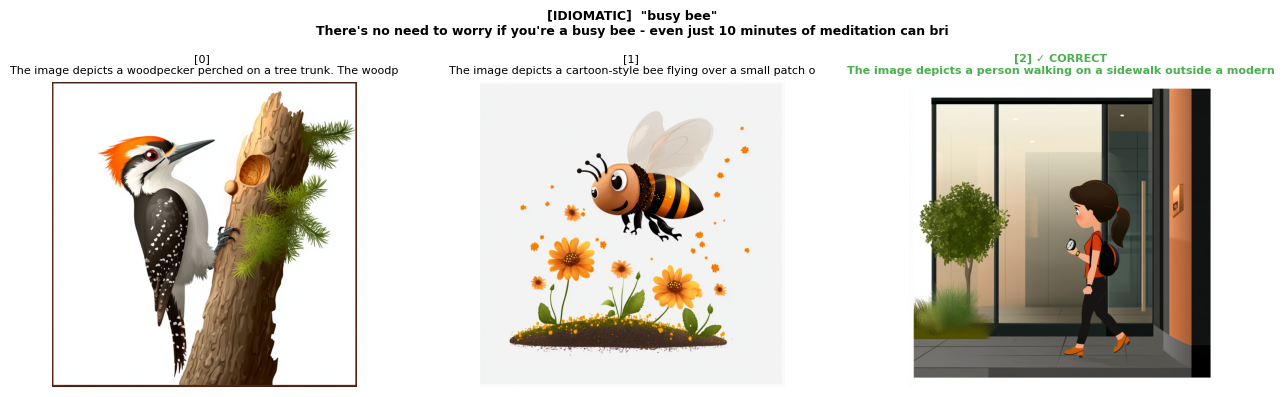

Predicted : 2  |  True : 2
Scores    : [-2.262, -2.27, 0.64]


In [8]:
MODEL_SAVE = '/content/drive/MyDrive/Advanced AI/task2_deberta'
demo_tok   = AutoTokenizer.from_pretrained(MODEL_SAVE)
demo_ce    = AutoModelForSequenceClassification.from_pretrained(
    MODEL_SAVE).to(device)
demo_ce    = demo_ce.float()
demo_ce.eval()

def demo_predict(s):
    q  = (f"Does this image correctly represent the meaning of "
          f"'{s['compound']}' in: {s['sentence']}")
    sc = []
    with torch.no_grad():
        for cap in s['captions']:
            enc = demo_tok(q, cap, max_length=128,
                           padding='max_length', truncation=True,
                           return_tensors='pt').to(device)
            sc.append(demo_ce(**enc).logits.squeeze().item())
    pred = int(np.argmax(sc))

    fig, axes = plt.subplots(1, 3, figsize=(13,4))
    for i in range(3):
        axes[i].imshow(load_img(s['images'][i]))
        axes[i].axis('off')
        is_pred = (i == pred)
        is_true = (i == s['true_label'])
        if is_pred and is_true:
            label = '✓ CORRECT'; color = '#4CAF50'
        elif is_pred:
            label = '✗ WRONG PRED'; color = '#F44336'
        elif is_true:
            label = '(TRUE)'; color = '#FF9800'
        else:
            label = ''; color = 'black'
        axes[i].set_title(
            f"[{i}] {label}\n{s['captions'][i][:65]}",
            fontsize=8, color=color,
            fontweight='bold' if label else 'normal')

    plt.suptitle(
        f'[{s["sent_type"].upper()}]  "{s["compound"]}"\n'
        f'{s["sentence"][:90]}',
        fontsize=9, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f"Predicted : {pred}  |  True : {s['true_label']}")
    print(f"Scores    : {[round(x,3) for x in sc]}")

DEMO_IDX = 8
demo_predict(test_samples[DEMO_IDX])